In [6]:
import os

print(os.listdir('/content'))

['.config', 'archive (2).zip', 'sample_data']


In [7]:
import zipfile

with zipfile.ZipFile('/content/archive (2).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("First ZIP Extracted!")

First ZIP Extracted!


In [8]:
import os

print(os.listdir('/content'))

['.config', 'archive (2).zip', 'archive.zip', 'sample_data']


In [9]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Second ZIP Extracted!")

Second ZIP Extracted!


In [10]:
import os

print(os.listdir('/content'))

['.config', 'gesture_small', 'archive (2).zip', 'archive.zip', 'sample_data']


In [11]:
import os

path = "/content/gesture_small"

files = os.listdir(path)

print("Total files:", len(files))
print(files[:10])

Total files: 1699
['10(1105)_S.jpg', '6(881)_S.jpg', '9(1647)_S.jpg', '6(1400)_S.jpg', '2(585)_S.jpg', '9(1652)_S.jpg', '9(1671)_S.jpg', '10(1730)_S.jpg', '3(89)_S.jpg', '7(912)_S.jpg']


Dataset Loaded
X Shape: (1697, 2500)
Y Shape: (1697,)

Training SVM...

Accuracy: 1.0

Classification Report:

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        39
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00        20
           5       1.00      1.00      1.00        35
           6       1.00      1.00      1.00        44
           7       1.00      1.00      1.00        34
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00        41
          10       1.00      1.00      1.00        40

    accuracy                           1.00       340
   macro avg       1.00      1.00      1.00       340
weighted avg       1.00      1.00      1.00       340



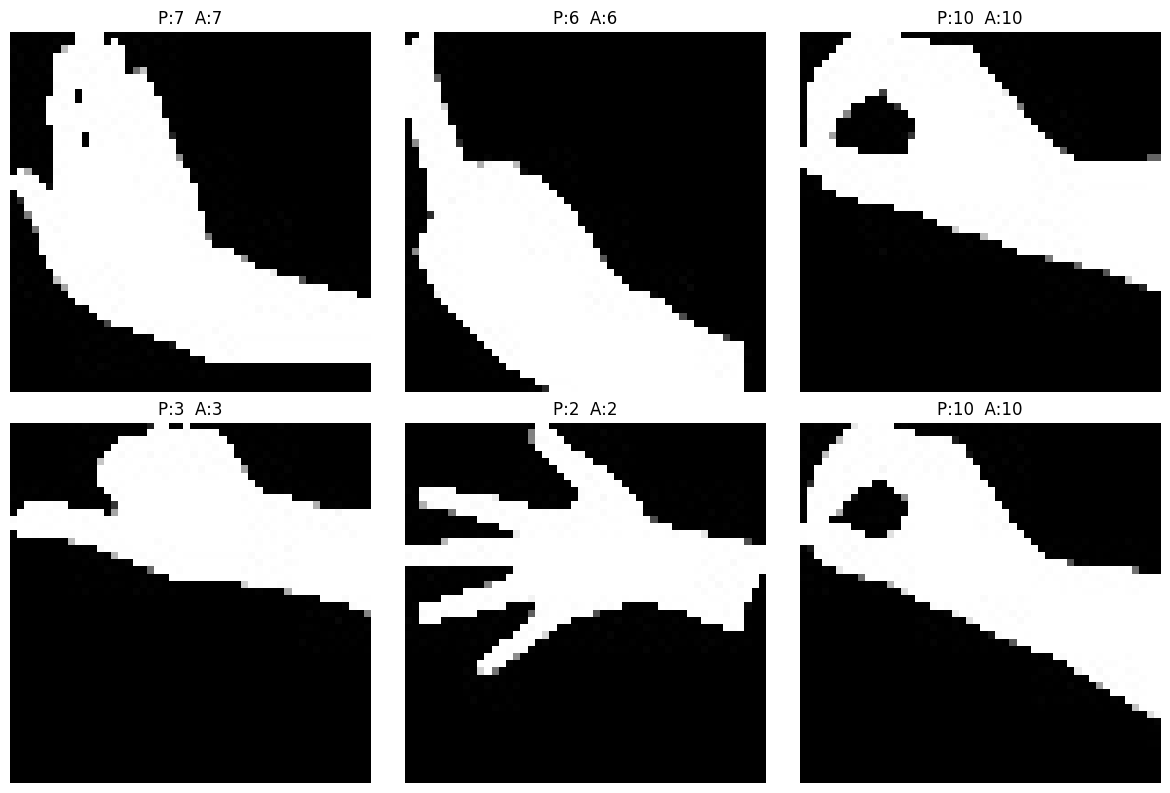

In [12]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

path = "/content/gesture_small"

data = []
labels = []

for file in os.listdir(path):

    if not file.endswith(".jpg"):
        continue

    label = int(file.split("(")[0])

    img = cv2.imread(
        os.path.join(path, file),
        cv2.IMREAD_GRAYSCALE
    )

    img = cv2.resize(img, (50, 50))

    data.append(img.flatten())
    labels.append(label)

X = np.array(data)
y = np.array(labels)

print("Dataset Loaded")
print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining SVM...")

svm = SVC(kernel='linear')

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# --------------------------
# Visual Results
# --------------------------

indices = np.random.choice(
    len(X_test),
    6,
    replace=False
)

plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):

    plt.subplot(2,3,i+1)

    img = X_test[idx].reshape(50,50)

    pred = svm.predict(
        [X_test[idx]]
    )[0]

    actual = y_test[idx]

    plt.imshow(img, cmap='gray')

    plt.title(
        f"P:{pred}  A:{actual}"
    )

    plt.axis('off')

plt.tight_layout()
plt.show()